In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import os
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_circles

# Generate Dataset

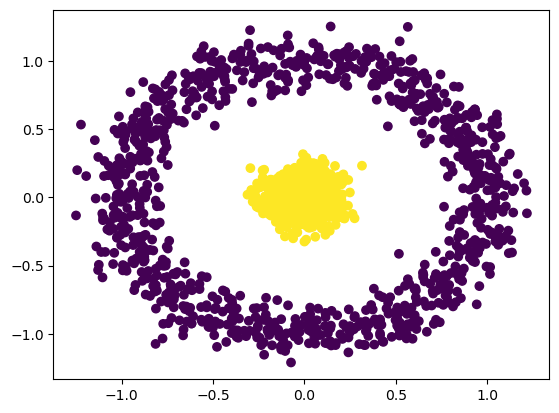

In [64]:
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles

nSamples = 2000
batch_size = 10

X, DataLabels = make_circles(n_samples=nSamples, factor=0.01, noise=0.1, random_state=42)
#X, y = make_moons(n_samples=200, noise=0.1, random_state=42)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, DataLabels, test_size=0.2, random_state=42)
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Plot Dataset
plt.scatter(X[:, 0], X[:, 1], c=DataLabels, cmap=plt.cm.viridis)
plt.show()


# Test that a vanilla FNN can solve this task and visualize its solution

In [3]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.hidden = nn.Linear(2, 3)  # 2 input neurons, 3 hidden neurons
        self.output = nn.Linear(3, 1)  # 1 output neuron

    def forward(self, x):
        x = torch.sigmoid(self.hidden(x))  # Sigmoid activation for hidden layer
        x = torch.sigmoid(self.output(x))  # Sigmoid activation for output layer
        return x

# Initialize the neural network
model = SimpleNN()

# Define loss function and optimizer
#criterion = nn.BCELoss()
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)


In [196]:
# Training loop
num_epochs = 500
for epoch in range(num_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluate the model
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    predicted = (outputs > 0.5).float()
    accuracy = (predicted == y_test_tensor).sum().item() / y_test_tensor.size(0)
    print(f'Accuracy: {accuracy * 100:.2f}%')


Epoch [100/500], Loss: 0.6684
Epoch [200/500], Loss: 0.5994
Epoch [300/500], Loss: 0.5557
Epoch [400/500], Loss: 0.4845
Epoch [500/500], Loss: 0.5081
Accuracy: 100.00%


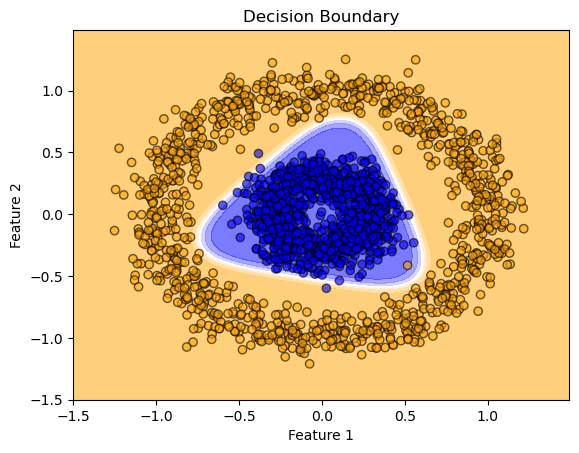

In [198]:
# Create a custom color map
cmap = mcolors.LinearSegmentedColormap.from_list('orange_white_blue', ['orange', 'white', 'blue'])

# Create a mesh grid to plot decision boundary
pltRange = 1.5
xx, yy = np.meshgrid(np.arange(-pltRange, pltRange, 0.01), np.arange(-pltRange, pltRange, 0.01))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.FloatTensor(grid)

# Get predictions for the grid points
with torch.no_grad():
    grid_outputs = model(grid_tensor)
    grid_pred = grid_outputs.numpy().reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, grid_pred, alpha=0.6, cmap=cmap)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap,  alpha=0.6, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary')
plt.show()


# Train multilayer Swinehart Abbott Model on classification

## Establishing and Visualizing Basis Features

Text(0.5, 1.0, 'Sum Units')

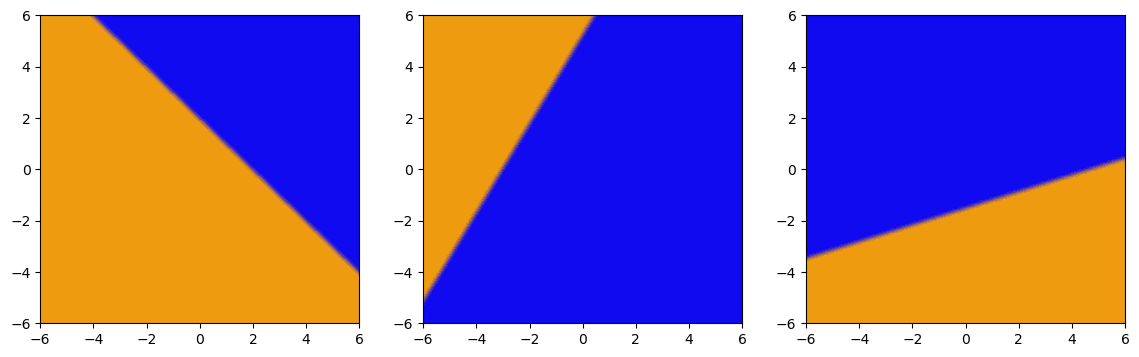

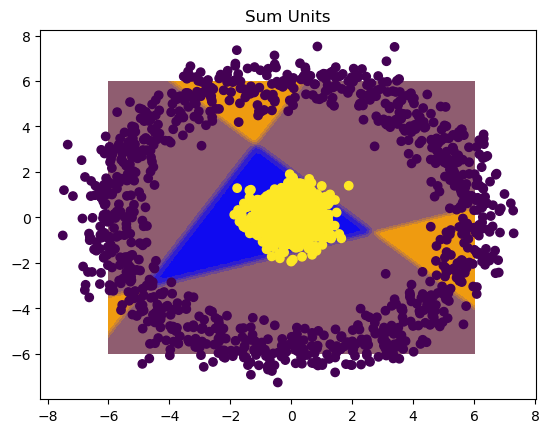

In [218]:

def standard_2dtanh(x, y):
    return np.tanh(x) + np.tanh(y)

def transform_2dtanh(xy, shifts, angle, gain):
    # Apply the shift
    shifted_x = xy[0] - shifts[0]
    shifted_y = xy[1] - shifts[1]
    
    # Apply the rotation
    rotation_matrix = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle), np.cos(angle)]
    ])
    rotated_xy = np.einsum('ij,jkl->ikl', rotation_matrix, np.array([shifted_x, shifted_y]))

    # Apply the gain
    gained_x = gain[0] * rotated_xy[0]
    gained_y = gain[1] * rotated_xy[1]
    
    # Apply the standard 2D tanh function
    z = standard_2dtanh(gained_x, gained_y)
    
    return z

# Generate a grid of points
pltRange = 6
x = np.linspace(-pltRange, pltRange, 100)
y = np.linspace(-pltRange, pltRange, 100)
xx, yy = np.meshgrid(x, y)


shifts = np.array([2, 0])  
gain = np.array([-10, 0])
angle = 3* np.pi / 4  
zz1 = transform_2dtanh((xx, yy), shifts, angle, gain)


shifts = np.array([-3, 0])  
gain = np.array([10, 0])
angle = np.pi / 6  
zz2 = transform_2dtanh((xx, yy), shifts, angle, gain)

shifts = np.array([0, -1.5])  
gain = np.array([-10, 0])
angle = 0.8 * np.pi / 2
zz3 = transform_2dtanh((xx, yy), shifts, angle, gain)


# Plot the result
cmap = mcolors.LinearSegmentedColormap.from_list('orange_white_blue', ['orange', 'blue'])
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.contourf(xx, yy, zz1, cmap=cmap)

plt.subplot(1,3,2)
plt.contourf(xx, yy, zz2, cmap=cmap)

plt.subplot(1,3,3)
plt.contourf(xx, yy, zz3, cmap=cmap)


nSamples = 2000
X, DataLabels = make_circles(n_samples=nSamples, factor=0.01, noise=0.1, random_state=42)
X = X * pltRange


weights = [-1.7, 1.7, 1.7]
zz_out = (weights[0]*zz1) + (weights[1]*zz2) + (weights[2]*zz3)
plt.figure()
plt.contourf(xx, yy, zz_out, cmap=cmap)
plt.scatter(X[:, 0], X[:, 1], c=DataLabels)
plt.title("Sum Units")


### Swinehart and Abbott Model

In [17]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        
        # Initialize shifts and gains as learnable parameters
        self.shifts1 = nn.Parameter(torch.tensor([2.0, 0.0]))
        self.gains1 = nn.Parameter(torch.tensor([-10.0, 0.0]))
        
        self.shifts2 = nn.Parameter(torch.tensor([-3.0, 0.0]))
        self.gains2 = nn.Parameter(torch.tensor([10.0, 0.0]))
        
        self.shifts3 = nn.Parameter(torch.tensor([0.0, -1.5]))
        self.gains3 = nn.Parameter(torch.tensor([-10.0, 0.0]))
        
        # Set angles as constants
        self.angles = nn.Parameter(torch.tensor([3 * np.pi / 4, np.pi / 6, 0.8 * np.pi / 2]), requires_grad=False)
        
        # Weight matrix for combining the units' outputs
        self.weights = torch.tensor([-1.7, 1.7, 1.7])

    # Define the 2D tanh transformation function
    def standard_2dtanh(self, x, y):
        return torch.tanh(x) + torch.tanh(y)

    def transform_2dtanh(self, xy, shifts, angle, gain):
        # Apply the shift
        shifted_x = xy[:, 0] - shifts[0]
        shifted_y = xy[:, 1] - shifts[1]
        
        # Apply the rotation
        cos_angle = torch.cos(angle)
        sin_angle = torch.sin(angle)
        rotation_matrix = torch.tensor([
            [cos_angle, -sin_angle],
            [sin_angle, cos_angle]
        ], dtype=torch.float32)
        rotated_xy = torch.einsum('ij,kj->ki', rotation_matrix, torch.stack([shifted_x, shifted_y], dim=1))

        # Apply the gain
        gained_x = gain[0] * rotated_xy[:, 0]
        gained_y = gain[1] * rotated_xy[:, 1]
        
        # Apply the standard 2D tanh function
        z = self.standard_2dtanh(gained_x, gained_y)
        
        return z
    
    def forward(self, x):
        out1 = self.transform_2dtanh(x, self.shifts1, self.angles[0], self.gains1)
        out2 = self.transform_2dtanh(x, self.shifts2, self.angles[1], self.gains2)
        out3 = self.transform_2dtanh(x, self.shifts3, self.angles[2], self.gains3)
        
        out = torch.stack((out1, out2, out3), dim=1)
        final_out = torch.matmul(out, self.weights).squeeze()

        return final_out


In [18]:
# Generate data
randomState = 0
pltRange = 3
nSamples = 2000
X, DataLabels = make_circles(n_samples=nSamples, factor=0.01, noise=0.1, random_state=42)
X = X * pltRange

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(DataLabels, dtype=torch.float32)
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.3, random_state=randomState)

# Initialize and Train the model
torch.manual_seed(randomState)
np.random.seed(randomState)

model = SimpleNN()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam([model.shifts1, model.shifts2, model.shifts3, model.gains1, model.gains2, model.gains3], lr=0.001)
#optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
n_epochs = 10000
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{n_epochs}], Loss: {loss.item():.4f}')

# Evaluate the model
model.eval()
with torch.no_grad():
    train_outputs = model(X_train)
    test_outputs = model(X_test)
    train_loss = criterion(train_outputs, y_train).item()
    test_loss = criterion(test_outputs, y_test).item()
    print(f'Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')


Epoch [100/10000], Loss: 0.9350
Epoch [200/10000], Loss: 0.7873
Epoch [300/10000], Loss: 0.7013
Epoch [400/10000], Loss: 0.6371
Epoch [500/10000], Loss: 0.5917
Epoch [600/10000], Loss: 0.5499
Epoch [700/10000], Loss: 0.5042
Epoch [800/10000], Loss: 0.4637
Epoch [900/10000], Loss: 0.4355
Epoch [1000/10000], Loss: 0.4146
Epoch [1100/10000], Loss: 0.3963
Epoch [1200/10000], Loss: 0.3791
Epoch [1300/10000], Loss: 0.3627
Epoch [1400/10000], Loss: 0.3471
Epoch [1500/10000], Loss: 0.3323
Epoch [1600/10000], Loss: 0.3182
Epoch [1700/10000], Loss: 0.3047
Epoch [1800/10000], Loss: 0.2920
Epoch [1900/10000], Loss: 0.2802
Epoch [2000/10000], Loss: 0.2696
Epoch [2100/10000], Loss: 0.2603
Epoch [2200/10000], Loss: 0.2523
Epoch [2300/10000], Loss: 0.2454
Epoch [2400/10000], Loss: 0.2393
Epoch [2500/10000], Loss: 0.2338
Epoch [2600/10000], Loss: 0.2288
Epoch [2700/10000], Loss: 0.2246
Epoch [2800/10000], Loss: 0.2212
Epoch [2900/10000], Loss: 0.2182
Epoch [3000/10000], Loss: 0.2154
Epoch [3100/10000],

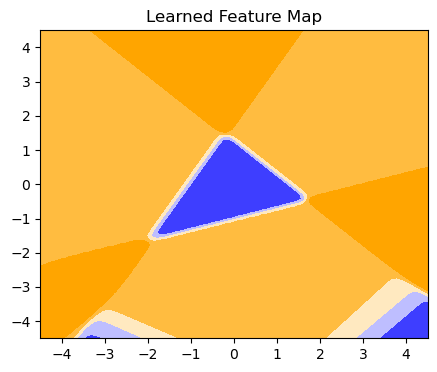

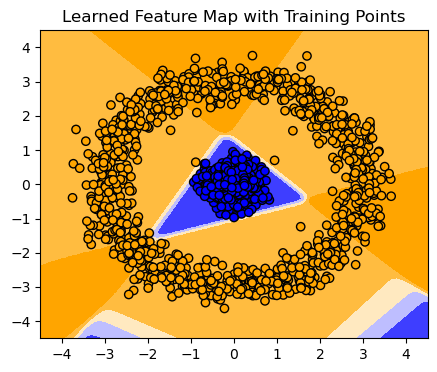

In [16]:
######################################## PLOT CODE
# Visualize the final learned feature map
 
xx, yy = np.meshgrid(np.linspace(-pltRange*1.5, pltRange*1.5, 100), np.linspace(-pltRange*1.5, pltRange*1.5, 100))
xy = np.stack([xx.ravel(), yy.ravel()], axis=1)
xy_tensor = torch.tensor(xy, dtype=torch.float32)

with torch.no_grad():
    zz1 = model.transform_2dtanh(xy_tensor, model.shifts1, model.angles[0], model.gains1)
    zz2 = model.transform_2dtanh(xy_tensor, model.shifts2, model.angles[1], model.gains2)
    zz3 = model.transform_2dtanh(xy_tensor, model.shifts3, model.angles[2], model.gains3)

    zz_final = (model.weights[0] * zz1) + (model.weights[1] * zz2) + (model.weights[2] * zz3)
    zz_final = zz_final.reshape(xx.shape)

    predictions = torch.sigmoid(model(X_tensor)).round().numpy()

# Plot the decision boundary
cmap = mcolors.LinearSegmentedColormap.from_list('orange_white_blue', ['orange', 'white','blue'])
cmap_pred = mcolors.ListedColormap(['orange', 'blue'])

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, zz_final, cmap=cmap, vmin=-2, vmax=2)
plt.title('Learned Feature Map')
plt.show()

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, zz_final, cmap=cmap, vmin=-2, vmax=2)
plt.scatter(X[:, 0], X[:, 1], c=predictions, cmap=cmap_pred, edgecolors='k')
plt.title('Learned Feature Map with Training Points')
plt.show()

# Now with weight learning

In [21]:
class SwinehartAbbottClassification(nn.Module):
    def __init__(self, manual_weights=None):
        super(SwinehartAbbottClassification, self).__init__()
        
        # Initialize shifts and gains as learnable parameters
        self.shifts1 = nn.Parameter(torch.tensor([2.0, 0.0]))
        self.gains1 = nn.Parameter(torch.tensor([-10.0, 0.0]))
        
        self.shifts2 = nn.Parameter(torch.tensor([-3.0, 0.0]))
        self.gains2 = nn.Parameter(torch.tensor([10.0, 0.0]))
        
        self.shifts3 = nn.Parameter(torch.tensor([0.0, -1.5]))
        self.gains3 = nn.Parameter(torch.tensor([-10.0, 0.0]))
        
        # Set angles as constants
        self.angles = nn.Parameter(torch.tensor([3 * np.pi / 4, np.pi / 6, 0.8 * np.pi / 2]), requires_grad=False)
        
        if manual_weights is None:
            self.weights = torch.tensor([-1.7, 1.7, 1.7])
        else:
            self.weights = manual_weights

    # Define the 2D tanh transformation function
    def standard_2dtanh(self, x, y):
        return torch.tanh(x) + torch.tanh(y)

    def transform_2dtanh(self, xy, shifts, angle, gain):
        # Apply the shift
        shifted_x = xy[:, 0] - shifts[0]
        shifted_y = xy[:, 1] - shifts[1]
        
        # Apply the rotation
        cos_angle = torch.cos(angle)
        sin_angle = torch.sin(angle)
        rotation_matrix = torch.tensor([
            [cos_angle, -sin_angle],
            [sin_angle, cos_angle]
        ], dtype=torch.float32)
        rotated_xy = torch.einsum('ij,kj->ki', rotation_matrix, torch.stack([shifted_x, shifted_y], dim=1))

        # Apply the gain
        gained_x = gain[0] * rotated_xy[:, 0]
        gained_y = gain[1] * rotated_xy[:, 1]
        
        # Apply the standard 2D tanh function
        z = self.standard_2dtanh(gained_x, gained_y)
        
        return z
    
    def forward(self, x):
        out1 = self.transform_2dtanh(x, self.shifts1, self.angles[0], self.gains1)
        out2 = self.transform_2dtanh(x, self.shifts2, self.angles[1], self.gains2)
        out3 = self.transform_2dtanh(x, self.shifts3, self.angles[2], self.gains3)
        
        out = torch.stack((out1, out2, out3), dim=1)
        final_out = torch.matmul(out, self.weights).squeeze()

        self.hidden_activations = out

        return final_out


In [35]:
# Generate data
randomState = 0
pltRange = 3
nSamples = 2000
X, DataLabels = make_circles(n_samples=nSamples, factor=0.01, noise=0.1, random_state=42)
X = X * pltRange

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(DataLabels, dtype=torch.float32)
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.3, random_state=randomState)
batch_size = len(X_train)

# Initialize and Train the model
torch.manual_seed(randomState)
np.random.seed(randomState)

has_controller = True
has_hebbian = True

controller_lr = 0.001
hebbian_lr = 0.0001
alpha = 3

model = SwinehartAbbottClassification()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam([model.shifts1, model.shifts2, model.shifts3, model.gains1, model.gains2, model.gains3], lr=controller_lr)


# Training loop
n_epochs = 10000
for epoch in range(n_epochs):

    if has_controller:
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

    if has_hebbian:

        L1_hebbian_update = (model.hidden_activations.T @ outputs) / batch_size

        with torch.no_grad():
            model.weights += L1_hebbian_update * hebbian_lr
            model.weights /= 3 #torch.sum(model.weights, dim=1, keepdim=True)
            model.weights *= alpha


    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{n_epochs}], Loss: {loss.item():.4f}')

# Evaluate the model
model.eval()
with torch.no_grad():
    train_outputs = model(X_train)
    test_outputs = model(X_test)
    train_loss = criterion(train_outputs, y_train).item()
    test_loss = criterion(test_outputs, y_test).item()
    print(f'Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')


Epoch [100/10000], Loss: 0.9458
Epoch [200/10000], Loss: 0.8017
Epoch [300/10000], Loss: 0.7172
Epoch [400/10000], Loss: 0.6534
Epoch [500/10000], Loss: 0.6077
Epoch [600/10000], Loss: 0.5632
Epoch [700/10000], Loss: 0.5129
Epoch [800/10000], Loss: 0.4696
Epoch [900/10000], Loss: 0.4401
Epoch [1000/10000], Loss: 0.4171
Epoch [1100/10000], Loss: 0.3959
Epoch [1200/10000], Loss: 0.3754
Epoch [1300/10000], Loss: 0.3554
Epoch [1400/10000], Loss: 0.3362
Epoch [1500/10000], Loss: 0.3178
Epoch [1600/10000], Loss: 0.3003
Epoch [1700/10000], Loss: 0.2839
Epoch [1800/10000], Loss: 0.2687
Epoch [1900/10000], Loss: 0.2548
Epoch [2000/10000], Loss: 0.2425
Epoch [2100/10000], Loss: 0.2317
Epoch [2200/10000], Loss: 0.2224
Epoch [2300/10000], Loss: 0.2142
Epoch [2400/10000], Loss: 0.2069
Epoch [2500/10000], Loss: 0.2001
Epoch [2600/10000], Loss: 0.1937
Epoch [2700/10000], Loss: 0.1877
Epoch [2800/10000], Loss: 0.1822
Epoch [2900/10000], Loss: 0.1769
Epoch [3000/10000], Loss: 0.1716
Epoch [3100/10000],

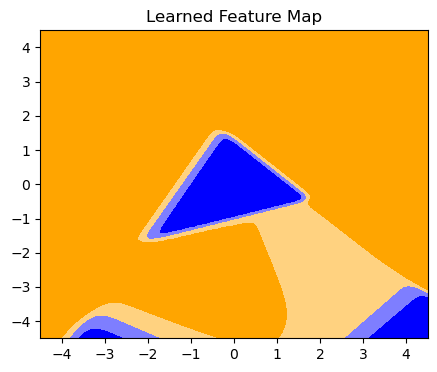

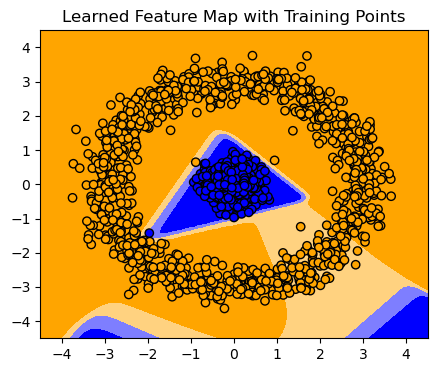

In [36]:
######################################## PLOT CODE
# Visualize the final learned feature map
 
xx, yy = np.meshgrid(np.linspace(-pltRange*1.5, pltRange*1.5, 100), np.linspace(-pltRange*1.5, pltRange*1.5, 100))
xy = np.stack([xx.ravel(), yy.ravel()], axis=1)
xy_tensor = torch.tensor(xy, dtype=torch.float32)

with torch.no_grad():
    zz1 = model.transform_2dtanh(xy_tensor, model.shifts1, model.angles[0], model.gains1)
    zz2 = model.transform_2dtanh(xy_tensor, model.shifts2, model.angles[1], model.gains2)
    zz3 = model.transform_2dtanh(xy_tensor, model.shifts3, model.angles[2], model.gains3)

    zz_final = (model.weights[0] * zz1) + (model.weights[1] * zz2) + (model.weights[2] * zz3)
    zz_final = zz_final.reshape(xx.shape)

    predictions = torch.sigmoid(model(X_tensor)).round().numpy()

# Plot the decision boundary
cmap = mcolors.LinearSegmentedColormap.from_list('orange_white_blue', ['orange', 'white','blue'])
cmap_pred = mcolors.ListedColormap(['orange', 'blue'])

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, zz_final, cmap=cmap, vmin=-2, vmax=2)
plt.title('Learned Feature Map')
plt.show()

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, zz_final, cmap=cmap, vmin=-2, vmax=2)
plt.scatter(X[:, 0], X[:, 1], c=predictions, cmap=cmap_pred, edgecolors='k')
plt.title('Learned Feature Map with Training Points')
plt.show()

## Assess Transfer Learning

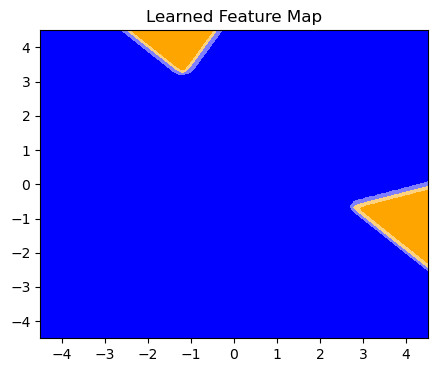

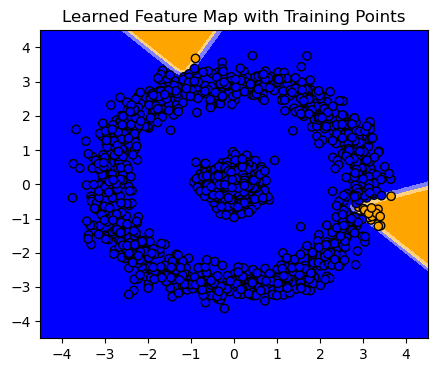

In [38]:
######################################## PLOT CODE
# Visualize the final learned feature map

new_model = SwinehartAbbottClassification(manual_weights=model.weights)

xx, yy = np.meshgrid(np.linspace(-pltRange*1.5, pltRange*1.5, 100), np.linspace(-pltRange*1.5, pltRange*1.5, 100))
xy = np.stack([xx.ravel(), yy.ravel()], axis=1)
xy_tensor = torch.tensor(xy, dtype=torch.float32)

with torch.no_grad():
    zz1 = new_model.transform_2dtanh(xy_tensor, new_model.shifts1, new_model.angles[0], new_model.gains1)
    zz2 = new_model.transform_2dtanh(xy_tensor, new_model.shifts2, new_model.angles[1], new_model.gains2)
    zz3 = new_model.transform_2dtanh(xy_tensor, new_model.shifts3, new_model.angles[2], new_model.gains3)

    zz_final = (new_model.weights[0] * zz1) + (new_model.weights[1] * zz2) + (new_model.weights[2] * zz3)
    zz_final = zz_final.reshape(xx.shape)

    predictions = torch.sigmoid(new_model(X_tensor)).round().numpy()

# Plot the decision boundary
cmap = mcolors.LinearSegmentedColormap.from_list('orange_white_blue', ['orange', 'white','blue'])
cmap_pred = mcolors.ListedColormap(['orange', 'blue'])

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, zz_final, cmap=cmap, vmin=-2, vmax=2)
plt.title('Learned Feature Map')
plt.show()

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, zz_final, cmap=cmap, vmin=-2, vmax=2)
plt.scatter(X[:, 0], X[:, 1], c=predictions, cmap=cmap_pred, edgecolors='k')
plt.title('Learned Feature Map with Training Points')
plt.show()